In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install required libraries
!pip install plotly scikit-learn pandas numpy matplotlib seaborn keras

In [3]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import init_notebook_mode  # Added for init_notebook_mode
from sklearn.preprocessing import LabelEncoder
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import keras

In [4]:
# Plotly setup
pio.templates.default = "none"
init_notebook_mode(connected=True)

In [51]:
# Import libraries
import os
import pandas as pd

# Define the folder path
folder_path = '/content/drive/MyDrive/cse366/366project_Spring25'  # Corrected folder path

# List of dataset files to merge
dataset_files = [
    'Autism Dataset for Toddlers.csv',
    'Autism Screening.csv',
    'Autism_Screening_Data_Combined.csv',
    'autism_screening.csv',
    'data_csv.csv',
    'Spectrum-Disorder.csv',
    'test.csv',
    'Toddler Autism dataset July 2018.csv'
]

# Initialize an empty list to store DataFrames
dataframes = []

# Load each dataset with detailed error handling
for file in dataset_files:
    file_path = os.path.join(folder_path, file)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            # Add a source column to track the origin of each row
            df['source'] = file  # This line adds the 'source' column
            dataframes.append(df)
            print(f"Loaded: {file} with shape {df.shape}")
        except pd.errors.ParserError as e:  # Handle parsing errors specifically
            print(f"Error parsing {file}: {e}")
            print(f"File path: {file_path}")
        except Exception as e:
            print(f"Error loading {file}: {e}")
            print(f"File path: {file_path}")
    else:
        print(f"File not found: {file}")
        print(f"File path: {file_path}")

# Merge all DataFrames
if dataframes:
    merged_df = pd.concat(dataframes, ignore_index=True, sort=False)

    # Handle missing columns by filling with NaN where necessary
    common_columns = set().union(*[df.columns for df in dataframes])
    for col in common_columns:
        if col not in merged_df.columns:
            merged_df[col] = pd.NA

    # Drop duplicate rows if any
    merged_df = merged_df.drop_duplicates()

    print(f"Merged dataset shape: {merged_df.shape}")
    print("Merged dataset columns:", merged_df.columns.tolist())
else:
    raise Exception("No datasets were loaded successfully.")

# Optional: Save the merged dataset to a new CSV file
merged_df.to_csv(os.path.join(folder_path, 'merged_dataset.csv'), index=False)
print("Merged dataset saved as 'merged_dataset.csv' in the folder.")
df['source'] = file  # This line adds the 'source' column

Loaded: Autism Dataset for Toddlers.csv with shape (1054, 20)
Loaded: Autism Screening.csv with shape (704, 22)
File not found: Autism_Screening_Data_Combined.csv
File path: /content/drive/MyDrive/cse366/366project_Spring25/Autism_Screening_Data_Combined.csv
Loaded: autism_screening.csv with shape (704, 22)
Loaded: data_csv.csv with shape (1985, 29)
Loaded: Spectrum-Disorder.csv with shape (704, 17)
File not found: test.csv
File path: /content/drive/MyDrive/cse366/366project_Spring25/test.csv
File not found: Toddler Autism dataset July 2018.csv
File path: /content/drive/MyDrive/cse366/366project_Spring25/Toddler Autism dataset July 2018.csv
Merged dataset shape: (5124, 59)
Merged dataset columns: ['Case_No', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_Mons', 'Qchat-10-Score', 'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Who completed the test', 'Class/ASD Traits ', 'source', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Sco

In [52]:
df= merged_df
df.head()

,Case_No,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,Depression,Global developmental delay/intellectual disability,Social/Behavioural Issues,Childhood Autism Rating Scale,Anxiety_disorder,Who_completed_the_test,ASD_traits,jaundice,autism,Class
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
# Select numeric feature columns for clustering (e.g., A1 to A10, Age_Mons, Qchat-10-Score)
feature_cols = [col for col in df.columns if col.startswith(('A', 'Age_Mons', 'Qchat-10-Score')) and col in df.select_dtypes(include=[np.number]).columns]
data = df[feature_cols].values

Handle Missing Values

In [68]:
# Drop columns with too many missing values first (e.g., more than 50%)
threshold = 0.5  # Drop columns with more than 50% NaNs
merged_df = merged_df.loc[:, merged_df.isnull().mean() < threshold]

# Then drop rows with missing target-related or important data
merged_df = merged_df.dropna(subset=merged_df.columns)  # Now safer


Double check 'target' variable

In [78]:
print(merged_df['target'].value_counts(normalize=True))

target
0    0.653175
1    0.346825
Name: proportion, dtype: float64


In [80]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')  # 5-fold cross-validation
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [1. 1. 1. 1. 1.]
Mean accuracy: 1.0


In [82]:
importances = model.feature_importances_
feature_names = X.columns # Fixed indentation

for i in range(len(feature_names)):
    print(f"{feature_names[i]}: {importances[i]}")

A1: 0.0035056573170888818
A2: 0.00019452493214062747
A3: 0.00036489682343191903
A4: 0.002618996928606637
A5: 0.006634320068258478
A6: 0.00832692164604952
A7: 0.02080723625229197
A8: 0.000702686025129926
A9: 0.001965964813022806
Sex: 0.3454876317349476
Ethnicity: 0.030417420795934996
Jaundice: 0.30366697706778106
Family_mem_with_ASD: 0.2753067655953156


In [86]:
X = merged_df.drop(columns=['target', 'source'])
y = merged_df['target']


 Encode Categorical Variables

In [87]:
label_encoders = {}
for col in merged_df.select_dtypes(include='object').columns:
    if col != 'source':  # Don't encode the source column
        le = LabelEncoder()
        merged_df[col] = le.fit_transform(merged_df[col])
        label_encoders[col] = le


In [88]:
# Step 6: Manually create a binary target column based on file source
# You can change the condition to whatever makes sense for your case
merged_df['target'] = merged_df['source'].apply(lambda x: 1 if 'Autism' in x else 0)


In [89]:
# Step 7: Split Features and Target
X = merged_df.drop(columns=['target', 'source'])
y = merged_df['target']


In [90]:
# Step 8: Split Data into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [91]:
# Step 9: Scale the Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [92]:
# Step 10: Train the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [93]:
# Step 11: Evaluate the Model
from sklearn.metrics import accuracy_score, classification_report # Import accuracy_score and classification_report

y_pred = model.predict(X_test)
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))

✅ Accuracy: 1.0

📊 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       389
           1       1.00      1.00      1.00       219

    accuracy                           1.00       608
   macro avg       1.00      1.00      1.00       608
weighted avg       1.00      1.00      1.00       608



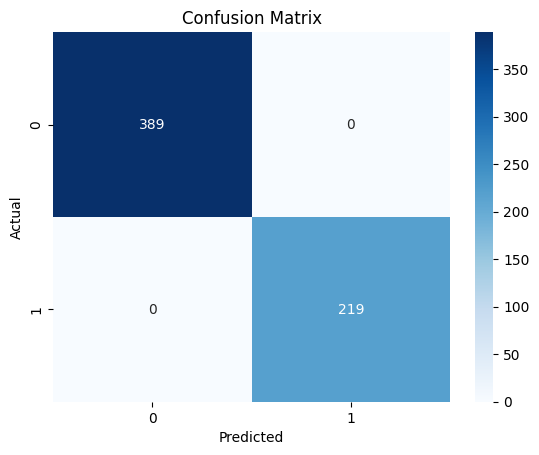

In [94]:
# Step 12: Confusion Matrix
from sklearn.metrics import confusion_matrix # Import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()